<a href="https://colab.research.google.com/github/Gurirath/VIT---EDA---Projects---Classwork--25BAI0153/blob/main/Experiment_6_1_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [5]:
mnist=fetch_openml('mnist_784',version=1, as_frame=False)

In [6]:
X=mnist.data
y=mnist.target.astype(int)

In [7]:
print("Number of samples:",X.shape[0])
print("Numbers of classes:",len(np.unique(y)))
print("Image dimensions: 28 * 28 (",X.shape[1],"pixels flattened)")

Number of samples: 70000
Numbers of classes: 10
Image dimensions: 28 * 28 ( 784 pixels flattened)


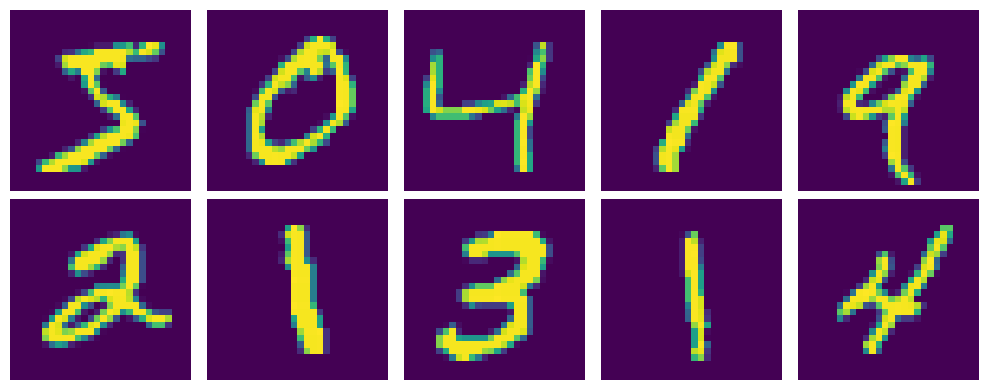

In [8]:
plt.figure(figsize=(10,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X[i].reshape(28,28))
  plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
X_norm=X/255.0

In [11]:
scaler= MinMaxScaler()
X_norm=scaler.fit_transform(X)

In [12]:
pca_full=PCA()
pca_full.fit(X_norm)

PCA()

In [13]:
explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
n_99 = np.argmax(cum_var >= 0.99) + 1

print("Components for 90% variance:", n_90)
print("Components for 95% variance:", n_95)
print("Components for 99% variance:", n_99)

Components for 90% variance: 87
Components for 95% variance: 154
Components for 99% variance: 331


In [14]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_norm)

pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X_norm)

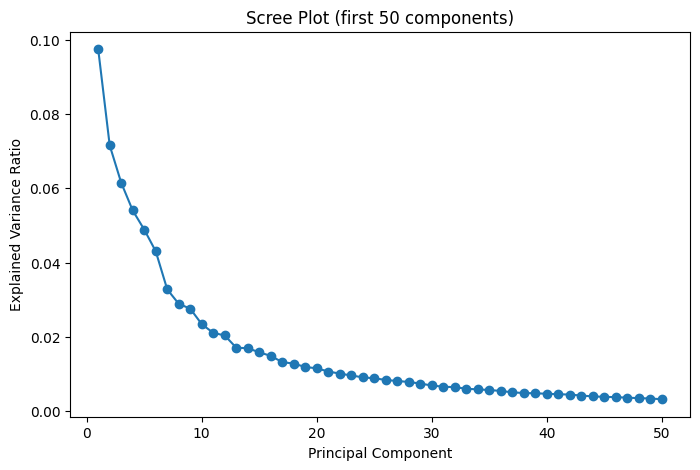

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), explained_var[:50], marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (first 50 components)")
plt.show()

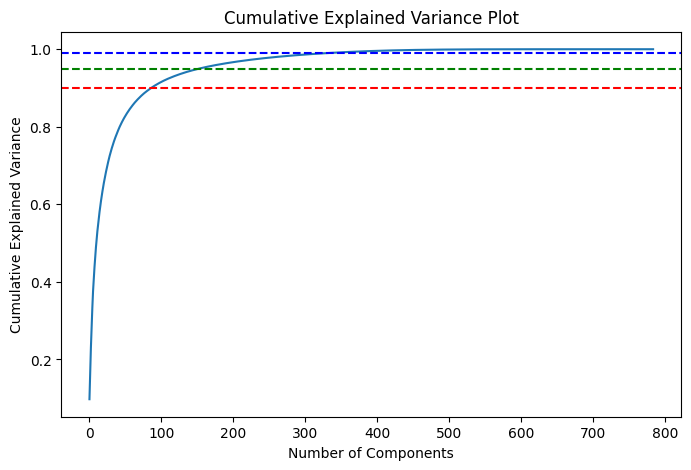

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(cum_var)
plt.axhline(y=0.90, color='r', linestyle='--')
plt.axhline(y=0.95, color='g', linestyle='--')
plt.axhline(y=0.99, color='b', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.show()

In [17]:
np.random.seed(42)
sample_idx = np.random.choice(X_norm.shape[0], size=5000, replace=False)

X_sample = X_norm[sample_idx]
X_pca50_sample = X_pca_50[sample_idx]
y_sample = y[sample_idx]

In [18]:
tsne_orig = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_orig = tsne_orig.fit_transform(X_sample)

tsne_pca = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_pca = tsne_pca.fit_transform(X_pca50_sample)

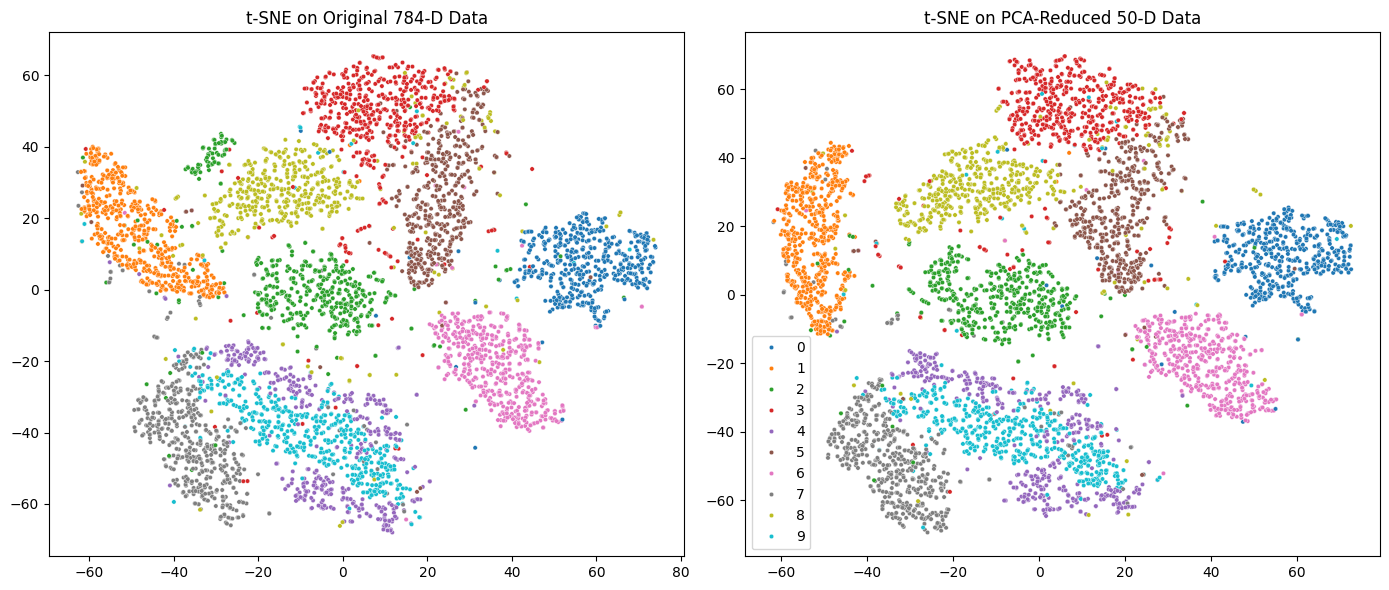

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_tsne_orig[:, 0], y=X_tsne_orig[:, 1], hue=y_sample, palette='tab10', s=10, ax=axes[0], legend=False)
axes[0].set_title("t-SNE on Original 784-D Data")

sns.scatterplot(x=X_tsne_pca[:, 0], y=X_tsne_pca[:, 1], hue=y_sample, palette='tab10', s=10, ax=axes[1], legend='full')
axes[1].set_title("t-SNE on PCA-Reduced 50-D Data")

plt.tight_layout()
plt.show()

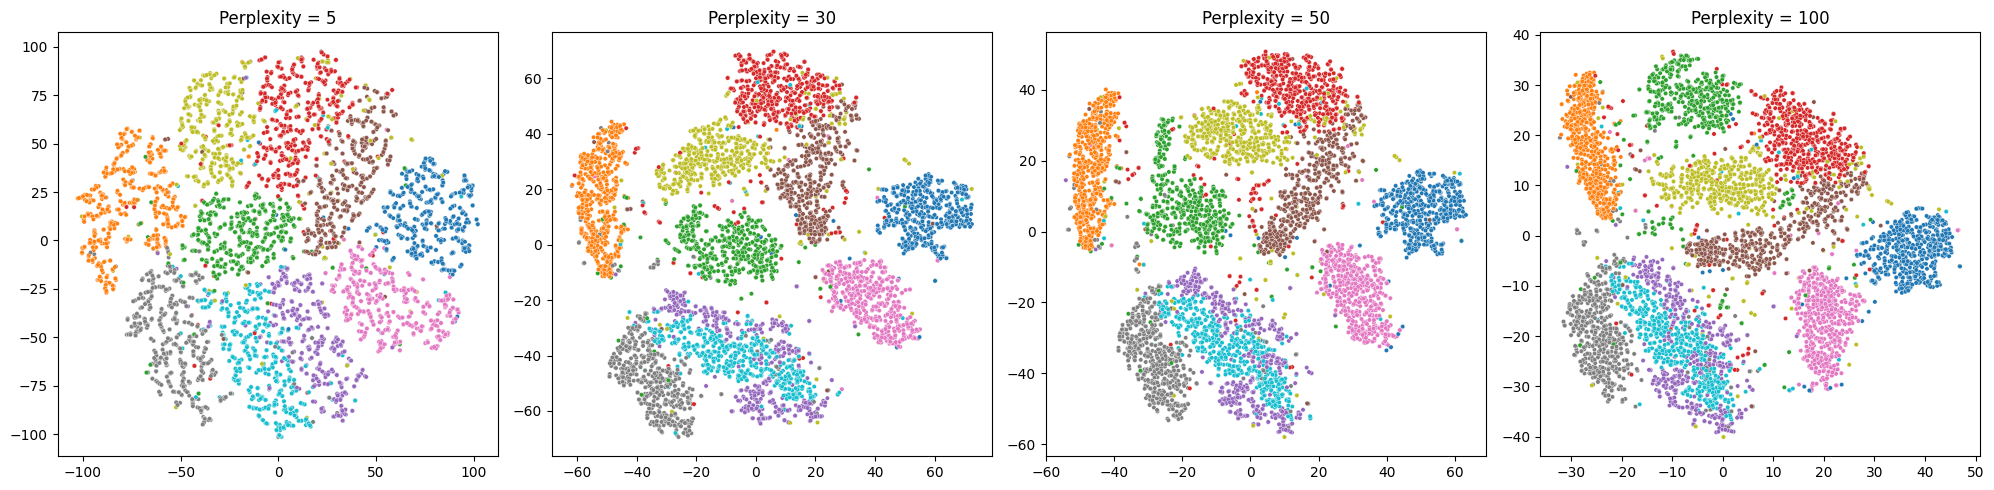

In [20]:
perplexities = [5, 30, 50, 100]

fig, axes = plt.subplots(1, len(perplexities), figsize=(20, 5))

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_t = tsne.fit_transform(X_pca50_sample)
    sns.scatterplot(x=X_t[:, 0], y=X_t[:, 1], hue=y_sample, palette='tab10', s=10, ax=axes[i], legend=False)
    axes[i].set_title(f"Perplexity = {p}")

plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y
)
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca_50, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
def evaluate_classifier(clf, X_train, X_test, y_train, y_test, label):
    start_train = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = clf.predict(X_test)
    pred_time = time.time() - start_pred

    acc = accuracy_score(y_test, y_pred)

    print(label)
    print("Accuracy:", acc)
    print("Training Time:", train_time, "seconds")
    print("Prediction Time:", pred_time, "seconds")
    print()

    return acc, train_time, pred_time

In [28]:
knn_orig = KNeighborsClassifier(n_neighbors=5)
evaluate_classifier(knn_orig, X_train_orig, X_test_orig, y_train, y_test, "KNN - Original 784-D Data")

knn_pca = KNeighborsClassifier(n_neighbors=5)
evaluate_classifier(knn_pca, X_train_pca, X_test_pca, y_train, y_test, "KNN - PCA 50-D Data")

KNN - Original 784-D Data
Accuracy: 0.9697142857142858
Training Time: 0.046822309494018555 seconds
Prediction Time: 46.22982621192932 seconds

KNN - PCA 50-D Data
Accuracy: 0.9755714285714285
Training Time: 0.0044248104095458984 seconds
Prediction Time: 6.769394159317017 seconds



(0.9755714285714285, 0.0044248104095458984, 6.769394159317017)

In [29]:
svm_orig = SVC(kernel='rbf')
evaluate_classifier(
    svm_orig,
    X_train_orig[:5000], X_test_orig[:2000],
    y_train[:5000], y_test[:2000],
    "SVM - Original 784-D Data (subset)"
)

svm_pca = SVC(kernel='rbf')
evaluate_classifier(
    svm_pca,
    X_train_pca[:5000], X_test_pca[:2000],
    y_train[:5000], y_test[:2000],
    "SVM - PCA 50-D Data (subset)"
)

SVM - Original 784-D Data (subset)
Accuracy: 0.943
Training Time: 3.0538437366485596 seconds
Prediction Time: 4.602237939834595 seconds

SVM - PCA 50-D Data (subset)
Accuracy: 0.954
Training Time: 0.8151733875274658 seconds
Prediction Time: 0.4679090976715088 seconds



(0.954, 0.8151733875274658, 0.4679090976715088)